In [1]:
"""
Starter Code: PINN Final Project
EN 553.481/681 Numerical Analysis
"""
import time
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super().__init__()
        layers = [nn.Linear(input_dim, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

def train_pinn(model, loss_fn, epochs, lr=1e-3, log_every=2000):
    """Train a PINN model.
    Returns: (loss_history, wall_clock_time_seconds)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_history = []
    t_start = time.time()
    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()
        loss = loss_fn(model)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
        if epoch % log_every == 0:
            print(f"  Epoch {epoch}/{epochs}, Loss = {loss.item():.6e}")
    wall_time = time.time() - t_start
    print(f"  Training time: {wall_time:.1f}s")
    return loss_history, wall_time

def plot_loss_curve(loss_history, title="Training Loss"):
    plt.figure(figsize=(6, 4))
    plt.semilogy(loss_history)
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.title(title); plt.grid(True, alpha=0.3)
    plt.tight_layout()

def plot_ode_comparison(model, exact_fn, t_range=(0, 5), label="PINN"):
    t = torch.linspace(*t_range, 1000, device=device).unsqueeze(1)
    with torch.no_grad():
        u_pred = model(t).cpu().numpy().flatten()
    t_np = t.cpu().numpy().flatten()
    u_ex = exact_fn(t_np)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(t_np, u_ex, 'k-', lw=2, label='Exact')
    axes[0].plot(t_np, u_pred, 'r--', lw=1.5, label=label)
    axes[0].set_xlabel('t'); axes[0].set_ylabel('u(t)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_title(f'{label} vs Exact')

    err = np.abs(u_pred - u_ex)
    axes[1].plot(t_np, err, 'b-')
    axes[1].set_xlabel('t'); axes[1].set_ylabel('|error|')
    axes[1].set_title(f'Pointwise Error (max = {err.max():.4e})')
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    print(f"  Max absolute error: {err.max():.6e}")
    return err.max()

def plot_heat_comparison(model, exact_fn, label="PINN"):
    """Plot PINN vs exact for heat eq. Returns relative L2 error."""
    Ntest = 100
    x = np.linspace(0, 1, Ntest)
    t = np.linspace(0, 0.5, Ntest)
    X, T = np.meshgrid(x, t)
    xt = np.column_stack([X.ravel(), T.ravel()])
    xt_t = torch.tensor(xt, dtype=torch.float32, device=device)
    with torch.no_grad():
        u_pred = model(xt_t).cpu().numpy().reshape(Ntest, Ntest)
    u_ex = exact_fn(X, T)
    err = np.abs(u_pred - u_ex)
    rel_l2 = np.sqrt(np.sum((u_pred - u_ex)**2)) / np.sqrt(np.sum(u_ex**2))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    c0 = axes[0].pcolormesh(X, T, u_pred, shading='auto', cmap='viridis')
    axes[0].set_xlabel('x'); axes[0].set_ylabel('t')
    axes[0].set_title(f'{label} Prediction'); plt.colorbar(c0, ax=axes[0])
    c1 = axes[1].pcolormesh(X, T, u_ex, shading='auto', cmap='viridis')
    axes[1].set_xlabel('x'); axes[1].set_ylabel('t')
    axes[1].set_title('Exact Solution'); plt.colorbar(c1, ax=axes[1])
    c2 = axes[2].pcolormesh(X, T, err, shading='auto', cmap='hot')
    axes[2].set_xlabel('x'); axes[2].set_ylabel('t')
    axes[2].set_title(f'|Error| (rel L2 = {rel_l2:.4e})'); plt.colorbar(c2, ax=axes[2])
    plt.tight_layout()
    print(f"  Relative L2 error: {rel_l2:.6e}")
    return rel_l2

## Problem 1.1:

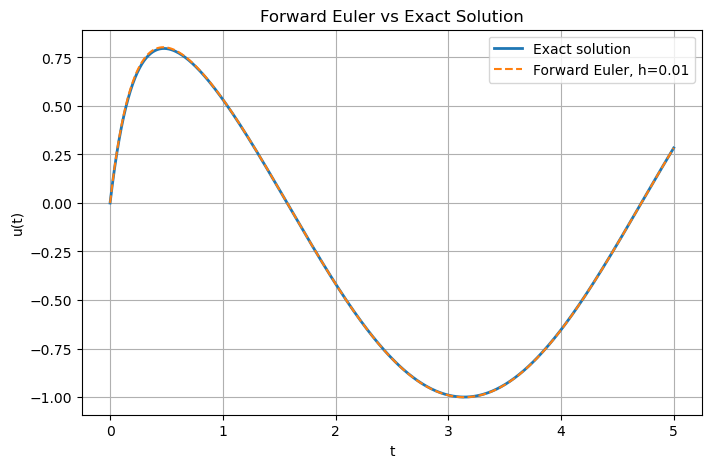

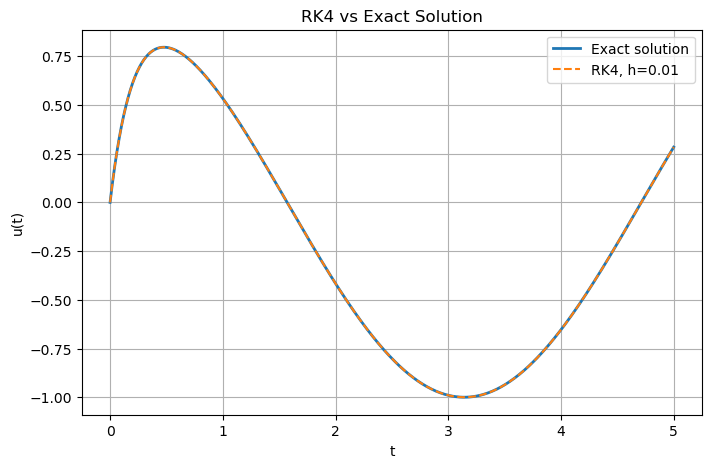

          method      h  global_error  observed_order
0  Forward Euler  0.010  1.002978e-02             NaN
1  Forward Euler  0.005  4.964941e-03        1.014441
2  Forward Euler  0.001  9.850170e-04        1.005008
3            RK4  0.010  2.164679e-08             NaN
4            RK4  0.005  1.325852e-09        4.029161
5            RK4  0.001  2.086664e-12        4.010247


In [2]:
import pandas as pd

## Problem 1.1
# Define f(t,u)
def ode_rhs(t, u):
    return -5 * u + 5 * np.cos(t) - np.sin(t)

# Exact solution 
def ode_exact(t):
    return np.cos(t) - np.exp(-5 * t)

# Forward Euler method
def forward_euler(h, T = 5.0):
    N = int(round(T / h))
    t = np.linspace(0, T, N + 1)
    u = np.zeros(N + 1)
    u[0] = 0.0

    for n in range(N):
        u[n+1] = u[n] + h * ode_rhs(t[n], u[n])

    return t, u

# RK4
def rk4(h, T = 5.0):
    N = int(round(T / h))
    t = np.linspace(0, T, N + 1)
    u = np.zeros(N + 1)
    u[0] = 0.0

    for n in range(N):
        tn = t[n]
        un = u[n]

        k1 = h * ode_rhs(tn, un)
        k2 = h * ode_rhs(tn + h / 2, un + k1 / 2)
        k3 = h * ode_rhs(tn + h / 2, un + k2 / 2)
        k4 = h * ode_rhs(tn + h, un + k3)

        u[n+1] = un + (k1 + 2 * k2 + 2 * k3 + k4) / 6

    return t, u


# Part(a): 
h = 0.01
t_euler, u_euler = forward_euler(h)
u_exact_euler = ode_exact(t_euler)

plt.figure(figsize = (8, 5))
plt.plot(t_euler, u_exact_euler, label= "Exact solution", linewidth= 2)
plt.plot(t_euler, u_euler, "--", label= "Forward Euler, h=0.01")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("Forward Euler vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()


# Part(b): 
t_rk4, u_rk4 = rk4(h)
u_exact_rk4 = ode_exact(t_rk4)

plt.figure(figsize=(8, 5))
plt.plot(t_rk4, u_exact_rk4, label= "Exact solution", linewidth= 2)
plt.plot(t_rk4, u_rk4, "--", label= "RK4, h=0.01")
plt.xlabel("t")
plt.ylabel("u(t)")
plt.title("RK4 vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()


# Part(c): 
hs = [0.01, 0.005, 0.001]

results = []

for method_name, method in [("Forward Euler", forward_euler), ("RK4", rk4)]:
    errors = []

    for h in hs:
        t, u_num = method(h)
        u_ex = ode_exact(t)

        error = np.max(np.abs(u_num - u_ex))
        errors.append(error)

    orders = [None]
    for i in range(1, len(hs)):
        p = np.log(errors[i - 1] / errors[i]) / np.log(hs[i - 1] / hs[i])
        orders.append(p)

    for h, error, order in zip(hs, errors, orders):
        results.append({
            "method": method_name,
            "h": h,
            "global_error": error,
            "observed_order": order
        })

df = pd.DataFrame(results)
print(df)

From the plots, both Forward Euler and RK4 with $h=0.01$ stay close to the exact solution. But the table shows that RK4 is much more accurate. The Forward Euler error is about $1.00\times 10^{-2}$ for $h=0.01$, while the RK4 error is about $2.16\times 10^{-8}$. The observed order is close to 1 for Forward Euler and close to 4 for RK4.

## Problem 1.2:

  Epoch 2000/10000, Loss = 5.638125e-03
  Epoch 4000/10000, Loss = 1.515433e-03
  Epoch 6000/10000, Loss = 1.541484e-03
  Epoch 8000/10000, Loss = 3.235036e-03
  Epoch 10000/10000, Loss = 2.408270e-03
  Training time: 6.1s
  Max absolute error: 1.365294e-02
ODE PINN-AD max error on 1000 test points: 1.365294e-02


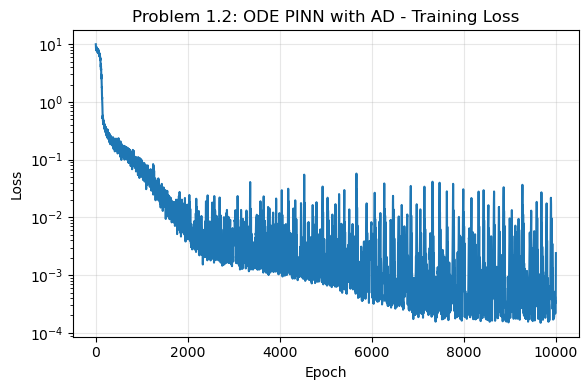

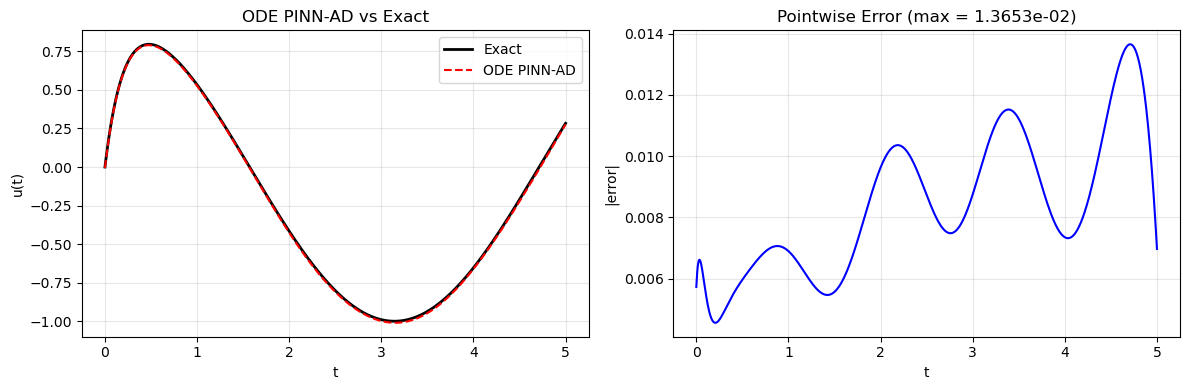

In [3]:
## Problem 1.2
# Part(a):
def compute_loss_ode_ad(model):
    # (i) Sample N_r = 500 collocation points uniformly from [0, 5]
    N_r = 500
    t_r = 5.0 * torch.rand(N_r, 1, device = device)
    t_r.requires_grad_(True)

    u = model(t_r)

    # (ii) Compute du/dt 
    du_dt = torch.autograd.grad(
        u,
        t_r,
        grad_outputs = torch.ones_like(u),
        create_graph = True
    )[0]

    # (iii) Residual loss
    residual = du_dt + 5 * u - 5 * torch.cos(t_r) + torch.sin(t_r)
    L_r = torch.mean(residual ** 2)

    # (iv) IC loss
    t0 = torch.zeros(1, 1, device = device)
    u0 = model(t0)
    L_ic = torch.mean(u0 ** 2)

    # (v) Return
    return L_r + 50 * L_ic

# Part(b):
model_ode_ad = PINN(
    input_dim = 1,
    hidden_dim = 32,
    num_layers = 3,
    output_dim = 1
).to(device)

# Train for 10,000 epochs
loss_ode_ad, time_ode_ad = train_pinn(
    model = model_ode_ad,
    loss_fn = compute_loss_ode_ad,
    epochs = 10000,
    lr = 1e-3,
    log_every = 2000
)

# Plot
plot_loss_curve(
    loss_ode_ad,
    title= "Problem 1.2: ODE PINN with AD - Training Loss"
)

error_ode_ad = plot_ode_comparison(
    model = model_ode_ad,
    exact_fn = ode_exact,
    t_range = (0, 5),
    label ="ODE PINN-AD"
)

print(f"ODE PINN-AD max error on 1000 test points: {error_ode_ad:.6e}")

In the training loss plot, the y-axis is on a log scale. The loss goes down over time, but it also has some jumps. This happens because the code uses a new random set of collocation points in each epoch. The network prediction is still very close to the exact solution. On 1000 test points, the maximum absolute error is about $1.37\times 10^{-2}$.

## Problem 1.3:

  Epoch 2000/10000, Loss = 1.578013e-03
  Epoch 4000/10000, Loss = 5.772217e-03
  Epoch 6000/10000, Loss = 8.077561e-04
  Epoch 8000/10000, Loss = 1.195371e-04
  Epoch 10000/10000, Loss = 1.635605e-04
  Training time: 7.8s
  Max absolute error: 2.596319e-03
ODE PINN-FDM max error on 1000 test points: 2.596319e-03


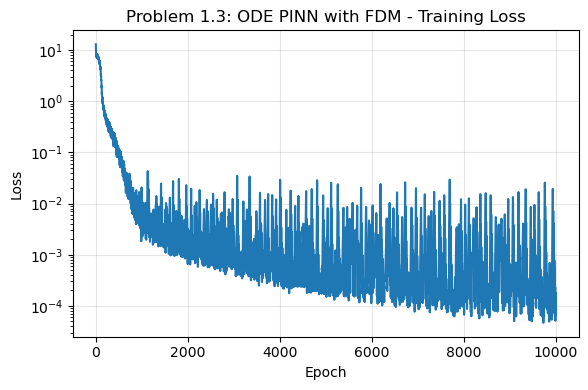

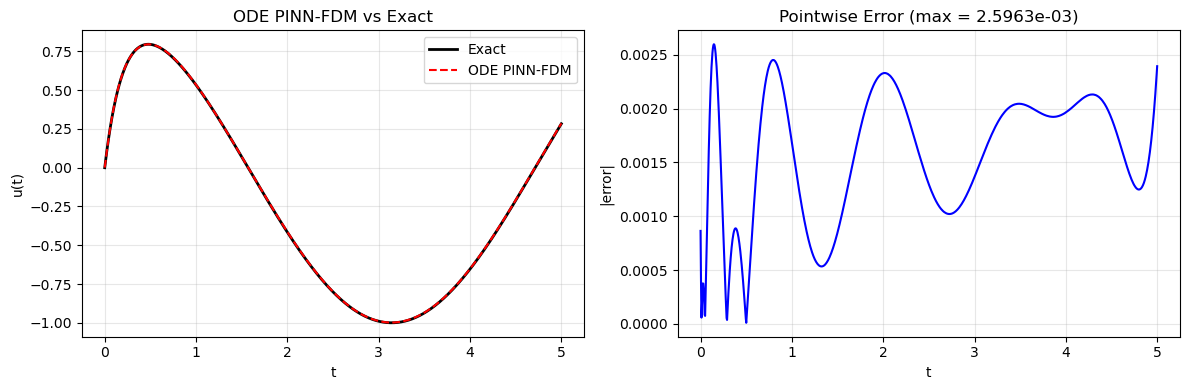

In [4]:
## Problem 1.3
# Part(a):
def compute_loss_ode_fdm(model, epsilon = 1e-3):
    N_r = 500
    t_r = epsilon + (5.0 - 2 * epsilon) * torch.rand(N_r, 1, device = device)

    u = model(t_r)

    u_plus = model(t_r + epsilon)
    u_minus = model(t_r - epsilon)
    du_dt_fdm = (u_plus - u_minus) / (2 * epsilon)

    # Residual
    residual = du_dt_fdm + 5 * u - 5 * torch.cos(t_r) + torch.sin(t_r)
    L_r = torch.mean(residual ** 2)

    # IC loss
    t0 = torch.zeros(1, 1, device = device)
    u0 = model(t0)
    L_ic = torch.mean(u0 ** 2)

    # Same weighting as Problem 1.2
    return L_r + 50 * L_ic

# Part(b):
model_ode_fdm = PINN(
    input_dim = 1,
    hidden_dim = 32,
    num_layers = 3,
    output_dim = 1
).to(device)

# Train with epsilon = 1e-3 for 10,000 epochs
loss_ode_fdm, time_ode_fdm = train_pinn(
    model = model_ode_fdm,
    loss_fn = lambda model: compute_loss_ode_fdm(model, epsilon = 1e-3),
    epochs = 10000,
    lr = 1e-3,
    log_every = 2000
)

# Plot 
plot_loss_curve(
    loss_ode_fdm,
    title="Problem 1.3: ODE PINN with FDM - Training Loss"
)

error_ode_fdm = plot_ode_comparison(
    model=model_ode_fdm,
    exact_fn=ode_exact,
    t_range=(0, 5),
    label="ODE PINN-FDM"
)

print(f"ODE PINN-FDM max error on 1000 test points: {error_ode_fdm:.6e}")

In the training loss plot, the loss goes down quickly at the beginning and then stays around a small value with some jumps. This is expected because the code uses new random collocation points during training. The prediction is very close to the exact solution. On 1000 test points, the maximum absolute error is about $2.60\times 10^{-3}$.

## Problem 1.4:

In [5]:
## Problem 1.4
# Part(a):
#Compare AD-PINN and FDM-PINN
comparison_table = pd.DataFrame([
    {
        "Method": "AD-PINN",
        "Final Training Loss": loss_ode_ad[-1],
        "Max Absolute Error": error_ode_ad,
        "Training Time (s)": time_ode_ad
    },
    {
        "Method": "FDM-PINN",
        "Final Training Loss": loss_ode_fdm[-1],
        "Max Absolute Error": error_ode_fdm,
        "Training Time (s)": time_ode_fdm
    }
])

comparison_table.style.format({
    "Final Training Loss": "{:.6e}",
    "Max Absolute Error": "{:.6e}",
    "Training Time (s)": "{:.2f}"
})

,Method,Final Training Loss,Max Absolute Error,Training Time (s)
0,AD-PINN,2.408270e-03,1.365294e-02,6.08
1,FDM-PINN,1.635605e-04,2.596319e-03,7.82


From the table, we observe that FDM-PINN is more accurate than AD-PINN, with a smaller final training loss and a smaller max absolute error. But AD-PINN trains faster.


Training FDM-PINN with epsilon = 1e-01
  Epoch 2000/10000, Loss = 2.743037e-03
  Epoch 4000/10000, Loss = 6.378031e-04
  Epoch 6000/10000, Loss = 1.851553e-03
  Epoch 8000/10000, Loss = 9.684085e-04
  Epoch 10000/10000, Loss = 2.514478e-03
  Training time: 8.2s

Training FDM-PINN with epsilon = 1e-02
  Epoch 2000/10000, Loss = 1.460403e-03
  Epoch 4000/10000, Loss = 5.606111e-03
  Epoch 6000/10000, Loss = 5.933017e-03
  Epoch 8000/10000, Loss = 5.391981e-04
  Epoch 10000/10000, Loss = 3.962566e-04
  Training time: 7.4s

Training FDM-PINN with epsilon = 1e-03
  Epoch 2000/10000, Loss = 4.996885e-03
  Epoch 4000/10000, Loss = 2.176727e-03
  Epoch 6000/10000, Loss = 4.444682e-03
  Epoch 8000/10000, Loss = 4.670403e-03
  Epoch 10000/10000, Loss = 1.034414e-03
  Training time: 7.4s

Training FDM-PINN with epsilon = 1e-04
  Epoch 2000/10000, Loss = 1.813495e-03
  Epoch 4000/10000, Loss = 1.509861e-03
  Epoch 6000/10000, Loss = 1.146827e-03
  Epoch 8000/10000, Loss = 6.714170e-04
  Epoch 100

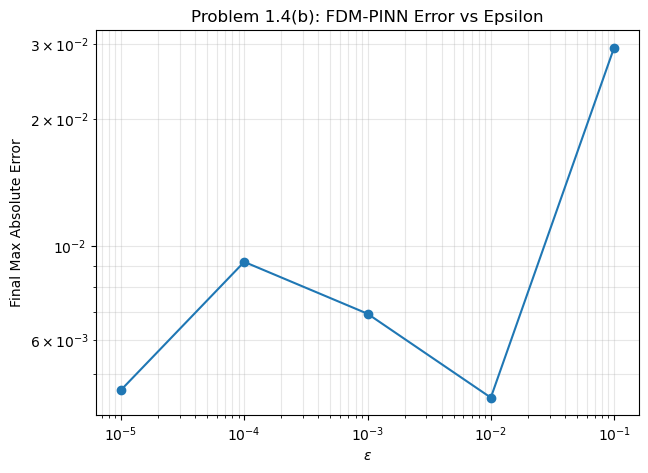

In [6]:
## Problem 1.4
# Part(b):
def compute_ode_max_error(model, exact_fn, t_range = (0, 5)):
    t = torch.linspace(*t_range, 1000, device = device).unsqueeze(1)

    with torch.no_grad():
        u_pred = model(t).cpu().numpy().flatten()

    t_np = t.cpu().numpy().flatten()
    u_ex = exact_fn(t_np)

    return np.max(np.abs(u_pred - u_ex))
    
eps_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
eps_errors = []

for eps in eps_values:
    print(f"\nTraining FDM-PINN with epsilon = {eps:.0e}")

    model_eps = PINN(
        input_dim = 1,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    _, _ = train_pinn(
        model = model_eps,
        loss_fn = lambda model, eps=eps: compute_loss_ode_fdm(model, epsilon = eps),
        epochs = 10000,
        lr = 1e-3,
        log_every = 2000
    )

    error_eps = compute_ode_max_error(
        model = model_eps,
        exact_fn = ode_exact,
        t_range = (0, 5)
    )

    eps_errors.append(error_eps)

plt.figure(figsize = (7, 5))
plt.loglog(
    eps_values,
    eps_errors,
    marker = "o"
)
plt.xlabel(r"$\epsilon$")
plt.ylabel("Final Max Absolute Error")
plt.title("Problem 1.4(b): FDM-PINN Error vs Epsilon")
plt.grid(True, which = "both", alpha = 0.3)
plt.show()

For the epsilon test, I trained the FDM-PINN with $\epsilon=10^{-1},10^{-2},10^{-3},10^{-4},10^{-5}$. The final max error does not decrease smoothly as $\epsilon$ gets smaller. From the plot, the smallest max error happens at about $\epsilon=10^{-2}$. When $\epsilon=10^{-1}$, the error is large. A very small $\epsilon$ also does not necessarily improve the accuracy. This can happen because the formula subtracts two very close values, $u_\theta(t+\epsilon)-u_\theta(t-\epsilon)$, which can increase round-off error.

## Problem 2.1:

Delta t = 1.219512e-02
r = 0.499512
L2 error at t = 0.5: 3.655397e-04


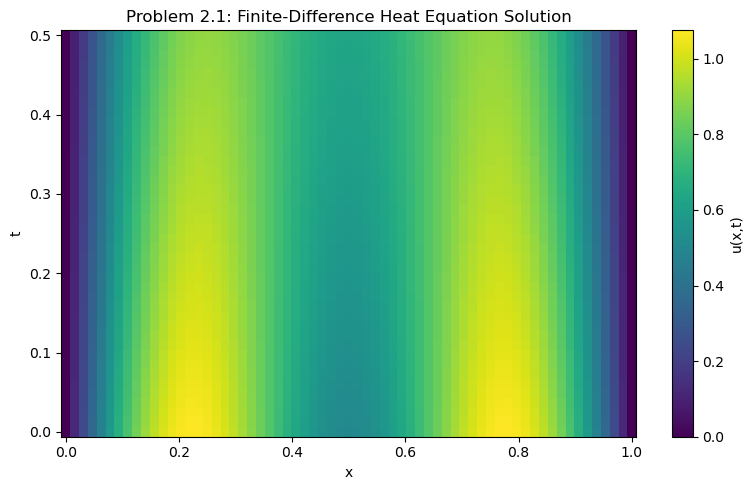

In [7]:
## Problem 2.1
v = 0.01
T_final = 0.5
dx = 1 / 64

# part(a):
dt_max = 0.5 * dx ** 2 / v
Nt = int(np.ceil(T_final / dt_max))
dt = T_final / Nt
r = v * dt / dx ** 2

print(f"Delta t = {dt:.6e}")
print(f"r = {r:.6f}")

Nx = 64
x = np.linspace(0, 1, Nx + 1)
t = np.linspace(0, T_final, Nt + 1)
U = np.zeros((Nt + 1, Nx + 1))

def heat_exact(x, t):
    return (
        np.exp(-v * np.pi ** 2 * t) * np.sin(np.pi * x)
        + 0.5 * np.exp(-9 * v * np.pi ** 2 * t) * np.sin(3 * np.pi * x)
    )
    
U[0, :] = np.sin(np.pi * x) + 0.5 * np.sin(3 * np.pi * x)

U[:, 0] = 0.0
U[:, -1] = 0.0

# Explicit Forward Euler finite-difference:
for n in range(Nt):
    for i in range(1, Nx):
        U[n + 1, i] = U[n, i] + r * (U[n, i + 1] - 2 * U[n, i] + U[n, i - 1])
        
# Part (b):
u_exact_final = heat_exact(x, T_final)
u_num_final = U[-1, :]

# L2 error:
l2_error = np.sqrt(dx * np.sum((u_num_final - u_exact_final) ** 2))

print(f"L2 error at t = 0.5: {l2_error:.6e}")

# Part (c): 
X, TT = np.meshgrid(x, t)

plt.figure(figsize=(8, 5))
plt.pcolormesh(X, TT, U, shading="auto")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Problem 2.1: Finite-Difference Heat Equation Solution")
plt.colorbar(label="u(x,t)")
plt.tight_layout()
plt.show()


The finite-difference solution satisfies the zero boundary conditions at $x=0$ and $x=1$. The heatmap shows that the high-value regions become slightly weaker as $t$ increases, which is expected for the heat equation. At $t=0.5$, the discrete $L^2$ error against the exact solution is $3.655397\times 10^{-4}$, so the finite-difference reference solution is accurate.

## Problem 2.2:

In [8]:
## Problem 2.2
# Part(a):
def compute_loss_heat_ad(model):
    # (i) Sample Nr = 10,000 interior points from (0,1) x (0,0.5]
    N_r = 10000
    x_r = torch.rand(N_r, 1, device = device)
    t_r = 0.5 * torch.rand(N_r, 1, device = device)

    xt_r = torch.cat([x_r, t_r], dim = 1)
    xt_r.requires_grad_(True)

    u = model(xt_r)

    # (ii) Compute 
    grad_u = torch.autograd.grad(
        u,
        xt_r,
        grad_outputs = torch.ones_like(u),
        create_graph = True
    )[0]

    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_u_x = torch.autograd.grad(
        u_x,
        xt_r,
        grad_outputs = torch.ones_like(u_x),
        create_graph = True
    )[0]

    u_xx = grad_u_x[:, 0:1]

    # (iii) Residual
    residual = u_t - v * u_xx
    L_r = torch.mean(residual ** 2)

    # (iv) IC loss
    N_ic = 200
    x_ic = torch.rand(N_ic, 1, device = device)
    t_ic = torch.zeros(N_ic, 1, device = device)
    xt_ic = torch.cat([x_ic, t_ic], dim = 1)

    u_ic_pred = model(xt_ic)
    u_ic_true = torch.sin(torch.pi * x_ic) + 0.5 * torch.sin(3 * torch.pi * x_ic)

    L_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    # (v) BC loss
    N_bc = 200
    t_bc = 0.5 * torch.rand(N_bc, 1, device = device)
 
    x_left = torch.zeros(N_bc, 1, device = device)
    x_right = torch.ones(N_bc, 1, device = device)

    xt_left = torch.cat([x_left, t_bc], dim = 1)
    xt_right = torch.cat([x_right, t_bc], dim = 1)

    u_left = model(xt_left)
    u_right = model(xt_right)

    L_bc = torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

    # (vi) Return
    return L_r + 20 * L_ic + 20 * L_bc

  Epoch 4000/20000, Loss = 6.534397e-03
  Epoch 8000/20000, Loss = 3.484942e-03
  Epoch 12000/20000, Loss = 1.176937e-03
  Epoch 16000/20000, Loss = 1.064946e-03
  Epoch 20000/20000, Loss = 1.089130e-03
  Training time: 194.6s
  Relative L2 error: 6.312507e-03
Heat PINN-AD relative L2 error on 100 x 100 test grid: 6.312507e-03


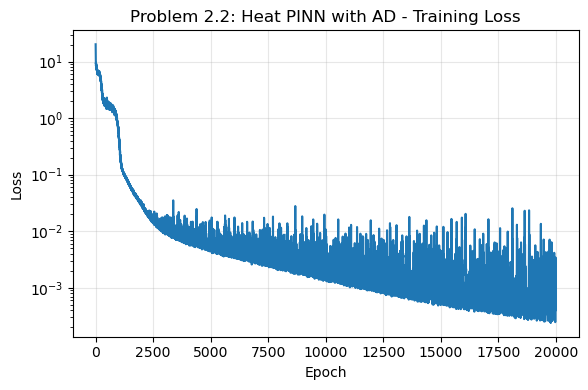

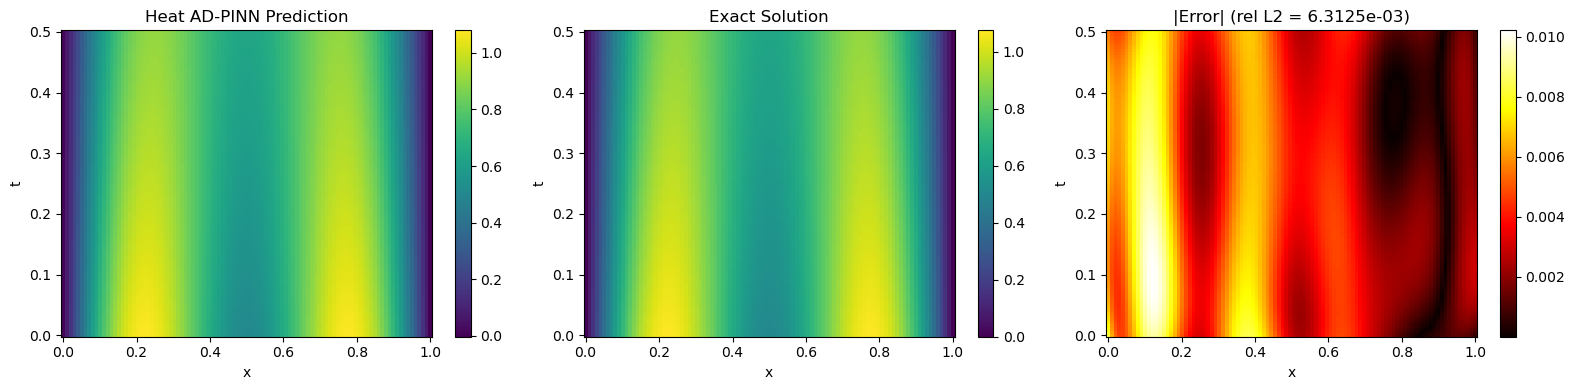

In [9]:
# Part (b):
model_heat_ad = PINN(
    input_dim = 2,
    hidden_dim = 32,
    num_layers = 3,
    output_dim = 1
).to(device)

# Train for 20,000 epochs
loss_heat_ad, time_heat_ad = train_pinn(
    model = model_heat_ad,
    loss_fn = compute_loss_heat_ad,
    epochs = 20000,
    lr = 1e-3,
    log_every = 4000
)

# Plot 
plot_loss_curve(
    loss_heat_ad,
    title = "Problem 2.2: Heat PINN with AD - Training Loss"
)

error_heat_ad = plot_heat_comparison(
    model = model_heat_ad,
    exact_fn = heat_exact,
    label = "Heat AD-PINN"
)

print(f"Heat PINN-AD relative L2 error on 100 x 100 test grid: {error_heat_ad:.6e}")

From the training loss plot, we observe that the loss goes down over time, with some jumps caused by random sampling during training. The predicted heatmap is very close to the exact heatmap, so the AD-PINN captures the main shape of the heat equation solution. The pointwise error heatmap shows small errors overall. On the $100\times100$ test grid, the relative $L^2$ error is about $6.31\times10^{-3}$.

## Problem 2.3

In [10]:
## Problem 2.3
# Part (a):
def compute_loss_heat_fdm(model, epsilon = 1e-3):
    N_r = 10000
    x_r = epsilon + (1 - 2 * epsilon) * torch.rand(N_r, 1, device = device)
    t_r = epsilon + (0.5 - 2 * epsilon) * torch.rand(N_r, 1, device = device)

    xt_r = torch.cat([x_r, t_r], dim = 1)

    u = model(xt_r)

    # u_t(x_i,t_i) ≈ [u(x_i,t_i+eps) - u(x_i,t_i-eps)] / (2eps)
    xt_t_plus = torch.cat([x_r, t_r + epsilon], dim = 1)
    xt_t_minus = torch.cat([x_r, t_r - epsilon], dim = 1)

    u_t_plus = model(xt_t_plus)
    u_t_minus = model(xt_t_minus)

    u_t_fdm = (u_t_plus - u_t_minus) / (2 * epsilon)

    # u_xx(x_i,t_i) ≈ [u(x_i+eps,t_i) - 2u(x_i,t_i) + u(x_i-eps,t_i)] / eps^2
    xt_x_plus = torch.cat([x_r + epsilon, t_r], dim = 1)
    xt_x_minus = torch.cat([x_r - epsilon, t_r], dim = 1)

    u_x_plus = model(xt_x_plus)
    u_x_minus = model(xt_x_minus)

    u_xx_fdm = (u_x_plus - 2 * u + u_x_minus) / (epsilon ** 2)

    # PDE residual
    residual = u_t_fdm - v * u_xx_fdm
    L_r = torch.mean(residual ** 2)

    # IC loss
    N_ic = 200
    x_ic = torch.rand(N_ic, 1, device=device)
    t_ic = torch.zeros(N_ic, 1, device=device)
    xt_ic = torch.cat([x_ic, t_ic], dim=1)

    u_ic_pred = model(xt_ic)
    u_ic_true = torch.sin(torch.pi * x_ic) + 0.5 * torch.sin(3 * torch.pi * x_ic)

    L_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    # BC loss
    N_bc = 200
    t_bc = 0.5 * torch.rand(N_bc, 1, device = device)

    x_left = torch.zeros(N_bc, 1, device = device)
    x_right = torch.ones(N_bc, 1, device = device)

    xt_left = torch.cat([x_left, t_bc], dim = 1)
    xt_right = torch.cat([x_right, t_bc], dim = 1)

    u_left = model(xt_left)
    u_right = model(xt_right)

    L_bc = torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

    # Same weighting as Problem 2.2
    return L_r + 20 * L_ic + 20 * L_bc

  Epoch 4000/20000, Loss = 1.610247e-03
  Epoch 8000/20000, Loss = 4.390032e-04
  Epoch 12000/20000, Loss = 3.841395e-04
  Epoch 16000/20000, Loss = 9.341770e-04
  Epoch 20000/20000, Loss = 1.874908e-04
  Training time: 198.9s
  Relative L2 error: 1.153832e-03
Heat FDM-PINN relative L2 error on 100 x 100 test grid: 1.153832e-03


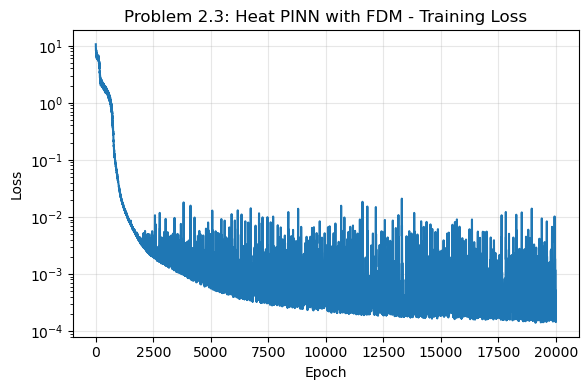

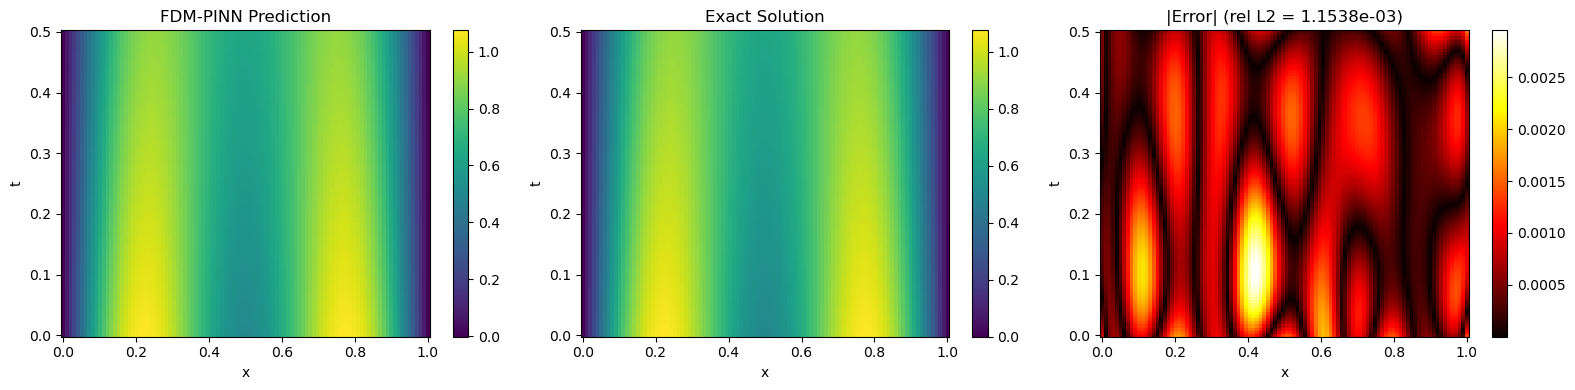

In [11]:
# Part(b):
model_heat_fdm = PINN(
    input_dim = 2,
    hidden_dim = 32,
    num_layers = 3,
    output_dim = 1
).to(device)

loss_heat_fdm, time_heat_fdm = train_pinn(
    model = model_heat_fdm,
    loss_fn = lambda model: compute_loss_heat_fdm(model, epsilon = 1e-3),
    epochs = 20000,
    lr = 1e-3,
    log_every = 4000
)

# Plot 
plot_loss_curve(
    loss_heat_fdm,
    title="Problem 2.3: Heat PINN with FDM - Training Loss"
)

error_heat_fdm = plot_heat_comparison(
    model=model_heat_fdm,
    exact_fn=heat_exact,
    label="FDM-PINN"
)

print(f"Heat FDM-PINN relative L2 error on 100 x 100 test grid: {error_heat_fdm:.6e}")

In the training loss plot, the loss decreases over time. The FDM-PINN prediction closely matches the exact solution heatmap. On the $100\times100$ test grid, the relative $L^2$ error is about $1.15\times10^{-3}$.

## Problem 2.4

In [12]:
# Part(a):
heat_comparison_table = pd.DataFrame([
    {
        "Method": "AD-PINN",
        "Final Loss": loss_heat_ad[-1],
        "Relative L2 Error": error_heat_ad,
        "Training Time (s)": time_heat_ad
    },
    {
        "Method": "FDM-PINN",
        "Final Loss": loss_heat_fdm[-1],
        "Relative L2 Error": error_heat_fdm,
        "Training Time (s)": time_heat_fdm
    }
])

heat_comparison_table.style.format({
    "Final Loss": "{:.6e}",
    "Relative L2 Error": "{:.6e}",
    "Training Time (s)": "{:.2f}"
})

,Method,Final Loss,Relative L2 Error,Training Time (s)
0,AD-PINN,1.089130e-03,6.312507e-03,194.64
1,FDM-PINN,1.874908e-04,1.153832e-03,198.90


The table compares AD-PINN and FDM-PINN for the heat equation. From this table, we can see that FDM-PINN has a smaller final loss and a smaller relative $L^2$ error than FDM-PINN. But AD-PINN takes slightly less training time.


Training Heat FDM-PINN with epsilon = 1e-01
  Epoch 4000/20000, Loss = 2.261177e-03
  Epoch 8000/20000, Loss = 8.788378e-04
  Epoch 12000/20000, Loss = 2.713380e-04
  Epoch 16000/20000, Loss = 3.607432e-04
  Epoch 20000/20000, Loss = 3.972992e-04
  Training time: 190.5s

Training Heat FDM-PINN with epsilon = 1e-02
  Epoch 4000/20000, Loss = 5.949900e-03
  Epoch 8000/20000, Loss = 1.307344e-03
  Epoch 12000/20000, Loss = 1.033640e-03
  Epoch 16000/20000, Loss = 3.118038e-04
  Epoch 20000/20000, Loss = 1.850813e-04
  Training time: 190.6s

Training Heat FDM-PINN with epsilon = 1e-03
  Epoch 4000/20000, Loss = 2.334267e-03
  Epoch 8000/20000, Loss = 3.721029e-04
  Epoch 12000/20000, Loss = 9.869533e-04
  Epoch 16000/20000, Loss = 1.126917e-04
  Epoch 20000/20000, Loss = 2.945186e-04
  Training time: 187.9s

Training Heat FDM-PINN with epsilon = 1e-04
  Epoch 4000/20000, Loss = 3.095775e-02
  Epoch 8000/20000, Loss = 2.237447e-02
  Epoch 12000/20000, Loss = 2.090923e-02
  Epoch 16000/2000

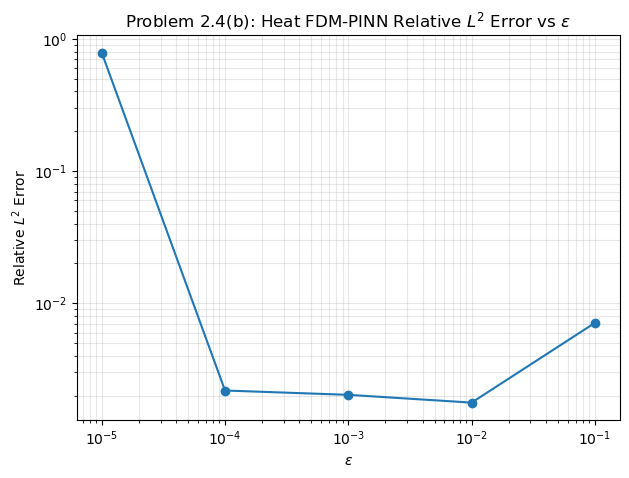

In [13]:
# Part(b):
def compute_heat_rel_l2_error(model, exact_fn):
    Ntest = 100
    x_test = np.linspace(0, 1, Ntest)
    t_test = np.linspace(0, 0.5, Ntest)
    X_test, T_test = np.meshgrid(x_test, t_test)

    xt = np.column_stack([X_test.ravel(), T_test.ravel()])
    xt_torch = torch.tensor(xt, dtype = torch.float32, device = device)

    with torch.no_grad():
        u_pred = model(xt_torch).cpu().numpy().reshape(Ntest, Ntest)

    u_ex = exact_fn(X_test, T_test)

    return np.sqrt(np.sum((u_pred - u_ex) ** 2)) / np.sqrt(np.sum(u_ex ** 2))


heat_eps_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
heat_eps_errors = []

for eps in heat_eps_values:
    print(f"\nTraining Heat FDM-PINN with epsilon = {eps:.0e}")

    model_heat_eps = PINN(
        input_dim = 2,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    _, _ = train_pinn(
        model = model_heat_eps,
        loss_fn = lambda model, eps = eps: compute_loss_heat_fdm(model, epsilon = eps),
        epochs = 20000,
        lr = 1e-3,
        log_every = 4000
    )

    rel_l2_eps = compute_heat_rel_l2_error(
        model = model_heat_eps,
        exact_fn = heat_exact
    )

    heat_eps_errors.append(rel_l2_eps)

plt.figure(figsize = (7, 5))
plt.loglog(
    heat_eps_values,
    heat_eps_errors,
    marker = "o"
)
plt.xlabel(r"$\epsilon$")
plt.ylabel(r"Relative $L^2$ Error")
plt.title(r"Problem 2.4(b): Heat FDM-PINN Relative $L^2$ Error vs $\epsilon$")
plt.grid(True, which = "both", alpha = 0.3)
plt.show()

For the heat equation FDM-PINN, we choose $\epsilon=10^{-1},10^{-2},10^{-3},10^{-4},10^{-5}$. The relative $L^2$ error does not decrease smoothly as $\epsilon$ becomes smaller. From the plot, the smallest error occurs around $\epsilon=10^{-2}$. When $\epsilon=10^{-5}$, the error becomes much larger again because the finite-difference formula subtracts very close values, and the round-off error is amplified.
<br><br>
This trade-off is more significant for the PDE than for the ODE because the heat equation requires a second derivative. The central difference approximation for $u_{xx}$ divides by $\epsilon^2$, so a very small $\epsilon$ can increase numerical round-off error more strongly than the first-derivative formula used in the ODE case.

Delta t = 0.01464844
r = 0.60000000


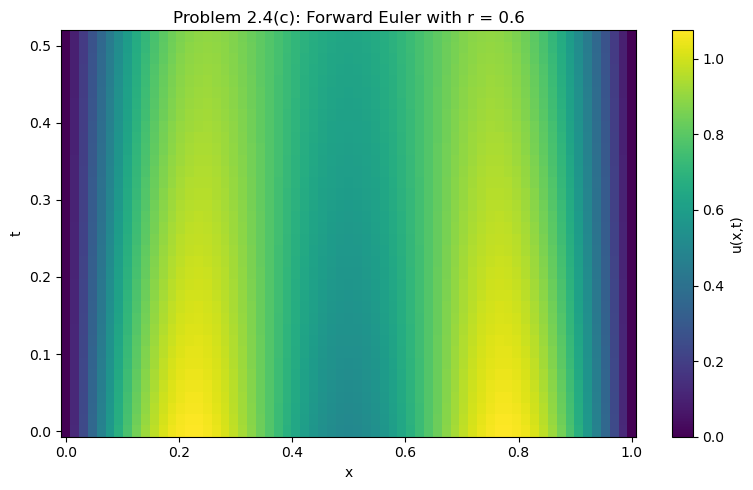

In [14]:
# Part(c):
r = 0.6
dx = 1 / 64
Nx = 64
T_final = 0.5

dt = r * dx ** 2 / v
Nt = int(np.ceil(T_final / dt))

t = np.linspace(0, Nt * dt, Nt + 1)
x = np.linspace(0, 1, Nx + 1)

U = np.zeros((Nt + 1, Nx + 1))

# Initial condition
U[0, :] = (
    np.sin(np.pi * x)
    + 0.5 * np.sin(3 * np.pi * x)
)

# Boundary conditions
U[:, 0] = 0.0
U[:, -1] = 0.0

# Forward Euler finite-difference with r = 0.6
for n in range(Nt):
    for i in range(1, Nx):
        U[n + 1, i] = (
            U[n, i]
            + r * (
                U[n, i + 1]
                - 2 * U[n, i]
                + U[n, i - 1]
            )
        )

print(f"Delta t = {dt:.8f}")
print(f"r = {r:.8f}")

X, TT = np.meshgrid(x, t)

plt.figure(figsize = (8, 5))
plt.pcolormesh(X, TT, U, shading = "auto")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Problem 2.4(c): Forward Euler with r = 0.6")
plt.colorbar(label = "u(x,t)")
plt.tight_layout()
plt.show()

For the Forward Euler finite-difference scheme, we used $r=0.6$, which violates the CFL stability condition $r\le 1/2$. The heatmap does not show a dramatic blow-up in this short run because the initial condition is smooth. But the scheme is theoretically unstable when $r>1/2$, so high-frequency errors or round-off noise can grow.

The PINN methods do not have the same CFL restriction because they are not explicit time-stepping methods. They train a neural network by minimizing the PDE residual over sampled points. So, their performance depends more on the optimizer, collocation points, network size, and, for FDM-PINN, the choice of $\epsilon$, rather than on a time step stability condition like Forward Euler.

## Problem 3

In [15]:
## Problem 3
# part (a):
summary_results = []

for _, row in df[df["h"] == 0.01].iterrows():
    summary_results.append({
        "Problem": "ODE",
        "Method": row["method"],
        "Error Metric": "Max absolute error",
        "Error": row["global_error"],
        "Time (s)": "N/A"
    })

# ODE PINN methods from Problems 1.2 and 1.3
summary_results.append({
    "Problem": "ODE",
    "Method": "AD-PINN",
    "Error Metric": "Max absolute error",
    "Error": error_ode_ad,
    "Time (s)": time_ode_ad
})

summary_results.append({
    "Problem": "ODE",
    "Method": "FDM-PINN",
    "Error Metric": "Max absolute error",
    "Error": error_ode_fdm,
    "Time (s)": time_ode_fdm
})

# Heat finite-difference method from Problem 2.1
summary_results.append({
    "Problem": "Heat",
    "Method": "Forward Euler FD",
    "Error Metric": "Discrete L2 error",
    "Error": l2_error,
    "Time (s)": "N/A"
})

# Heat PINN methods from Problems 2.2 and 2.3
summary_results.append({
    "Problem": "Heat",
    "Method": "AD-PINN",
    "Error Metric": "Relative L2 error",
    "Error": error_heat_ad,
    "Time (s)": time_heat_ad
})

summary_results.append({
    "Problem": "Heat",
    "Method": "FDM-PINN",
    "Error Metric": "Relative L2 error",
    "Error": error_heat_fdm,
    "Time (s)": time_heat_fdm
})

summary_table = pd.DataFrame(summary_results)

summary_table.style.format({
    "Error": "{:.6e}"
})

,Problem,Method,Error Metric,Error,Time (s)
0,ODE,Forward Euler,Max absolute error,1.002978e-02,N/A
1,ODE,RK4,Max absolute error,2.164679e-08,N/A
2,ODE,AD-PINN,Max absolute error,1.365294e-02,6.081904
3,ODE,FDM-PINN,Max absolute error,2.596319e-03,7.824590
4,Heat,Forward Euler FD,Discrete L2 error,3.655397e-04,N/A
5,Heat,AD-PINN,Relative L2 error,6.312507e-03,194.641538
6,Heat,FDM-PINN,Relative L2 error,1.153832e-03,198.895761


The table summarizes the errors for all methods in the ODE and heat equation problems. For the ODE, RK4 is the most accurate method, with a very small max absolute error. Forward Euler is easier to implement, but its error is much larger. For the ODE PINN methods, FDM-PINN gives a smaller error than AD-PINN in this run, but it takes a little more training time.

For the heat equation, the Forward Euler finite-difference method gives a small discrete $L^2$ error. For the heat PINN methods, FDM-PINN also gives a smaller relative $L^2$ error than AD-PINN in this run. However, both PINN methods take much longer to train than the classical finite-difference method. 


Training ODE AD-PINN with N_r = 100
  Epoch 2000/10000, Loss = 2.616695e-03
  Epoch 4000/10000, Loss = 2.408518e-03
  Epoch 6000/10000, Loss = 4.739815e-03
  Epoch 8000/10000, Loss = 7.018567e-04
  Epoch 10000/10000, Loss = 1.666125e-04
  Training time: 4.4s

Training ODE FDM-PINN with N_r = 100
  Epoch 2000/10000, Loss = 6.859274e-03
  Epoch 4000/10000, Loss = 6.662065e-04
  Epoch 6000/10000, Loss = 8.660744e-04
  Epoch 8000/10000, Loss = 3.834152e-04
  Epoch 10000/10000, Loss = 2.311544e-03
  Training time: 5.9s

Training ODE AD-PINN with N_r = 500
  Epoch 2000/10000, Loss = 2.033290e-03
  Epoch 4000/10000, Loss = 6.380986e-04
  Epoch 6000/10000, Loss = 6.907440e-04
  Epoch 8000/10000, Loss = 4.019999e-03
  Epoch 10000/10000, Loss = 2.455750e-03
  Training time: 5.2s

Training ODE FDM-PINN with N_r = 500
  Epoch 2000/10000, Loss = 5.669854e-03
  Epoch 4000/10000, Loss = 6.785576e-03
  Epoch 6000/10000, Loss = 9.721015e-03
  Epoch 8000/10000, Loss = 2.031359e-03
  Epoch 10000/10000, 

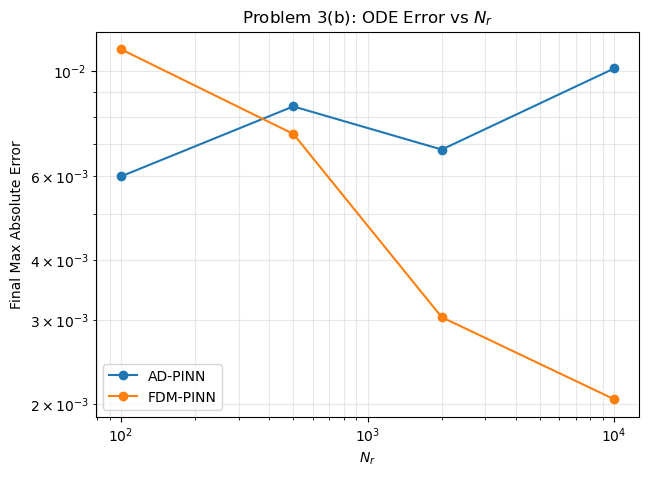


Training Heat AD-PINN with N_r = 500
  Epoch 4000/20000, Loss = 2.882286e-03
  Epoch 8000/20000, Loss = 1.330257e-03
  Epoch 12000/20000, Loss = 7.659177e-04
  Epoch 16000/20000, Loss = 3.376633e-04
  Epoch 20000/20000, Loss = 1.272399e-04
  Training time: 24.9s

Training Heat FDM-PINN with N_r = 500
  Epoch 4000/20000, Loss = 4.530228e-03
  Epoch 8000/20000, Loss = 4.139826e-03
  Epoch 12000/20000, Loss = 3.210235e-04
  Epoch 16000/20000, Loss = 1.642896e-03
  Epoch 20000/20000, Loss = 5.165065e-04
  Training time: 29.7s

Training Heat AD-PINN with N_r = 2000
  Epoch 4000/20000, Loss = 1.637799e-03
  Epoch 8000/20000, Loss = 3.690674e-04
  Epoch 12000/20000, Loss = 5.757922e-04
  Epoch 16000/20000, Loss = 4.567187e-04
  Epoch 20000/20000, Loss = 1.094642e-03
  Training time: 54.3s

Training Heat FDM-PINN with N_r = 2000
  Epoch 4000/20000, Loss = 4.047769e-03
  Epoch 8000/20000, Loss = 1.195286e-03
  Epoch 12000/20000, Loss = 4.205633e-04
  Epoch 16000/20000, Loss = 2.900420e-04
  Ep

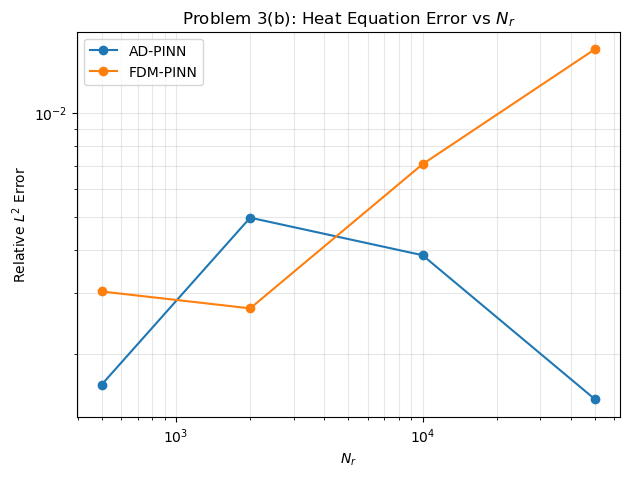

In [16]:
# Part(b):
# Helper functions 
def compute_ode_max_error(model, exact_fn, t_range = (0, 5)):
    t_test = np.linspace(t_range[0], t_range[1], 1000).reshape(-1, 1)
    t_torch = torch.tensor(t_test, dtype = torch.float32, device = device)

    with torch.no_grad():
        u_pred = model(t_torch).cpu().numpy().flatten()

    u_true = exact_fn(t_test.flatten())
    return np.max(np.abs(u_pred - u_true))


def compute_heat_rel_l2_error(model, exact_fn):
    Ntest = 100
    x_test = np.linspace(0, 1, Ntest)
    t_test = np.linspace(0, 0.5, Ntest)

    X_test, T_test = np.meshgrid(x_test, t_test)

    xt = np.column_stack([X_test.ravel(), T_test.ravel()])
    xt_torch = torch.tensor(xt, dtype = torch.float32, device = device)

    with torch.no_grad():
        u_pred = model(xt_torch).cpu().numpy().reshape(Ntest, Ntest)

    u_exact = exact_fn(X_test, T_test)

    return np.sqrt(np.sum((u_pred - u_exact) ** 2)) / np.sqrt(np.sum(u_exact ** 2))

# ODE loss functions with variable N_r
def compute_loss_ode_ad_Nr(model, N_r = 500):
    t_r = 5.0 * torch.rand(N_r, 1, device = device)
    t_r.requires_grad_(True)

    u = model(t_r)

    du_dt = torch.autograd.grad(
        u,
        t_r,
        grad_outputs = torch.ones_like(u),
        create_graph = True
    )[0]

    residual = du_dt + 5 * u - 5 * torch.cos(t_r) + torch.sin(t_r)
    L_r = torch.mean(residual ** 2)

    t0 = torch.zeros(1, 1, device = device)
    u0 = model(t0)
    L_ic = torch.mean(u0 ** 2)

    return L_r + 50 * L_ic


def compute_loss_ode_fdm_Nr(model, epsilon = 1e-3, N_r = 500):
    t_r = epsilon + (5.0 - 2 * epsilon) * torch.rand(N_r, 1, device = device)

    u = model(t_r)

    u_plus = model(t_r + epsilon)
    u_minus = model(t_r - epsilon)

    du_dt_fdm = (u_plus - u_minus) / (2 * epsilon)

    residual = du_dt_fdm + 5 * u - 5 * torch.cos(t_r) + torch.sin(t_r)
    L_r = torch.mean(residual ** 2)

    t0 = torch.zeros(1, 1, device=device)
    u0 = model(t0)
    L_ic = torch.mean(u0 ** 2)

    return L_r + 50 * L_ic

# Heat equation (PDE) loss functions with variable N_r
def compute_loss_heat_ad_Nr(model, N_r = 10000):
    x_r = torch.rand(N_r, 1, device = device)
    t_r = 0.5 * torch.rand(N_r, 1, device = device)

    xt_r = torch.cat([x_r, t_r], dim = 1)
    xt_r.requires_grad_(True)

    u = model(xt_r)

    grad_u = torch.autograd.grad(
        u,
        xt_r,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

    u_x = grad_u[:, 0:1]
    u_t = grad_u[:, 1:2]

    grad_u_x = torch.autograd.grad(
        u_x,
        xt_r,
        grad_outputs = torch.ones_like(u_x),
        create_graph = True
    )[0]

    u_xx = grad_u_x[:, 0:1]

    residual = u_t - v * u_xx
    L_r = torch.mean(residual ** 2)

    N_ic = 200
    x_ic = torch.rand(N_ic, 1, device = device)
    t_ic = torch.zeros(N_ic, 1, device = device)
    xt_ic = torch.cat([x_ic, t_ic], dim = 1)

    u_ic_pred = model(xt_ic)
    u_ic_true = torch.sin(torch.pi * x_ic) + 0.5 * torch.sin(3 * torch.pi * x_ic)

    L_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    N_bc = 200
    t_bc = 0.5 * torch.rand(N_bc, 1, device = device)

    x_left = torch.zeros(N_bc, 1, device = device)
    x_right = torch.ones(N_bc, 1, device = device)

    xt_left = torch.cat([x_left, t_bc], dim= 1)
    xt_right = torch.cat([x_right, t_bc], dim= 1)

    u_left = model(xt_left)
    u_right = model(xt_right)

    L_bc = torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

    return L_r + 20 * L_ic + 20 * L_bc


def compute_loss_heat_fdm_Nr(model, epsilon = 1e-3, N_r = 10000):
    x_r = epsilon + (1 - 2 * epsilon) * torch.rand(N_r, 1, device = device)
    t_r = epsilon + (0.5 - 2 * epsilon) * torch.rand(N_r, 1, device = device)

    xt_r = torch.cat([x_r, t_r], dim = 1)
    u = model(xt_r)

    xt_t_plus = torch.cat([x_r, t_r + epsilon], dim = 1)
    xt_t_minus = torch.cat([x_r, t_r - epsilon], dim = 1)

    u_t_plus = model(xt_t_plus)
    u_t_minus = model(xt_t_minus)

    u_t_fdm = (u_t_plus - u_t_minus) / (2 * epsilon)

    xt_x_plus = torch.cat([x_r + epsilon, t_r], dim = 1)
    xt_x_minus = torch.cat([x_r - epsilon, t_r], dim = 1)

    u_x_plus = model(xt_x_plus)
    u_x_minus = model(xt_x_minus)

    u_xx_fdm = (u_x_plus - 2 * u + u_x_minus) / (epsilon ** 2)

    residual = u_t_fdm - v * u_xx_fdm
    L_r = torch.mean(residual ** 2)

    N_ic = 200
    x_ic = torch.rand(N_ic, 1, device = device)
    t_ic = torch.zeros(N_ic, 1, device = device)
    xt_ic = torch.cat([x_ic, t_ic], dim = 1)

    u_ic_pred = model(xt_ic)
    u_ic_true = torch.sin(torch.pi * x_ic) + 0.5 * torch.sin(3 * torch.pi * x_ic)

    L_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

    N_bc = 200
    t_bc = 0.5 * torch.rand(N_bc, 1, device = device)

    x_left = torch.zeros(N_bc, 1, device = device)
    x_right = torch.ones(N_bc, 1, device = device)

    xt_left = torch.cat([x_left, t_bc], dim = 1)
    xt_right = torch.cat([x_right, t_bc], dim = 1)

    u_left = model(xt_left)
    u_right = model(xt_right)

    L_bc = torch.mean(u_left ** 2) + torch.mean(u_right ** 2)

    return L_r + 20 * L_ic + 20 * L_bc

# ODE experiment

ode_Nr_values = [100, 500, 2000, 10000]

ode_error_ad = []
ode_error_fdm = []

epochs_ode_exp = 10000

for N_r in ode_Nr_values:
    print(f"\nTraining ODE AD-PINN with N_r = {N_r}")

    model_ad = PINN(
        input_dim = 1,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    train_pinn(
        model = model_ad,
        loss_fn = lambda model, N_r = N_r: compute_loss_ode_ad_Nr(model, N_r = N_r),
        epochs = epochs_ode_exp,
        lr = 1e-3,
        log_every = 2000
    )

    error_ad = compute_ode_max_error(
        model = model_ad,
        exact_fn = ode_exact,
        t_range = (0, 5)
    )

    ode_error_ad.append(error_ad)

    print(f"\nTraining ODE FDM-PINN with N_r = {N_r}")

    model_fdm = PINN(
        input_dim = 1,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    train_pinn(
        model = model_fdm,
        loss_fn = lambda model, N_r = N_r: compute_loss_ode_fdm_Nr(
            model,
            epsilon = 1e-3,
            N_r = N_r
        ),
        epochs = epochs_ode_exp,
        lr = 1e-3,
        log_every = 2000
    )

    error_fdm = compute_ode_max_error(
        model = model_fdm,
        exact_fn = ode_exact,
        t_range = (0, 5)
    )

    ode_error_fdm.append(error_fdm)

# Plot ODE final error vs N_r
plt.figure(figsize = (7, 5))

plt.loglog(ode_Nr_values, ode_error_ad, marker = "o", label = "AD-PINN")
plt.loglog(ode_Nr_values, ode_error_fdm, marker = "o", label = "FDM-PINN")

plt.xlabel(r"$N_r$")
plt.ylabel("Final Max Absolute Error")
plt.title(r"Problem 3(b): ODE Error vs $N_r$")
plt.grid(True, which = "both", alpha = 0.3)
plt.legend()
plt.show()

# Heat equation (PDE) 
heat_Nr_values = [500, 2000, 10000, 50000]

heat_error_ad = []
heat_error_fdm = []

epochs_heat_exp = 20000

for N_r in heat_Nr_values:
    print(f"\nTraining Heat AD-PINN with N_r = {N_r}")

    model_ad = PINN(
        input_dim = 2,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    train_pinn(
        model = model_ad,
        loss_fn = lambda model, N_r = N_r: compute_loss_heat_ad_Nr(model, N_r = N_r),
        epochs = epochs_heat_exp,
        lr = 1e-3,
        log_every = 4000
    )

    error_ad = compute_heat_rel_l2_error(
        model = model_ad,
        exact_fn = heat_exact
    )

    heat_error_ad.append(error_ad)

    print(f"\nTraining Heat FDM-PINN with N_r = {N_r}")

    model_fdm = PINN(
        input_dim = 2,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    train_pinn(
        model = model_fdm,
        loss_fn = lambda model, N_r = N_r: compute_loss_heat_fdm_Nr(
            model,
            epsilon = 1e-3,
            N_r = N_r
        ),
        epochs = epochs_heat_exp,
        lr = 1e-3,
        log_every = 4000
    )

    error_fdm = compute_heat_rel_l2_error(
        model = model_fdm,
        exact_fn = heat_exact
    )

    heat_error_fdm.append(error_fdm)

# Plot Heat equation final error vs N_r
plt.figure(figsize = (7, 5))

plt.loglog(heat_Nr_values, heat_error_ad, marker = "o", label = "AD-PINN")
plt.loglog(heat_Nr_values, heat_error_fdm, marker = "o", label = "FDM-PINN")

plt.xlabel(r"$N_r$")
plt.ylabel(r"Relative $L^2$ Error")
plt.title(r"Problem 3(b): Heat Equation Error vs $N_r$")
plt.grid(True, which = "both", alpha = 0.3)
plt.legend()
plt.show()

Changing $N_r$ changes how many collocation points are used to approximate the residual loss. This is similar to quadrature, using more points usually gives a better approximation of the average residual over the domain. However, the final error does not always decrease as $N_r$ increases, because PINN training also depends on random sampling, initialization, and optimization. In this run, the ODE FDM-PINN improves as $N_r$ increases, but the other curves are not monotone.

In [17]:
# Part(c):
network_configs = [
    {
        "Network": "Small",
        "hidden_dim": 16,
        "num_layers": 2
    },
    {
        "Network": "Large",
        "hidden_dim": 64,
        "num_layers": 5
    }
]

network_results = []

epochs_ode_net = 10000
epochs_heat_net = 20000

for config in network_configs:
    hidden_dim = config["hidden_dim"]
    num_layers = config["num_layers"]
    network_name = config["Network"]

    print(f"\nTraining ODE AD-PINN with {network_name} network")

    model_ode_ad_net = PINN(
        input_dim = 1,
        hidden_dim = hidden_dim,
        num_layers = num_layers,
        output_dim = 1
    ).to(device)

    _, time_ode_ad_net = train_pinn(
        model = model_ode_ad_net,
        loss_fn = lambda model: compute_loss_ode_ad_Nr(model, N_r=500),
        epochs = epochs_ode_net,
        lr = 1e-3,
        log_every = 2000
    )

    error_ode_ad_net = compute_ode_max_error(
        model = model_ode_ad_net,
        exact_fn = ode_exact,
        t_range = (0, 5),
    )

    network_results.append({
        "Problem": "ODE",
        "Method": "AD-PINN",
        "Network": network_name,
        "Layers": num_layers,
        "Neurons": hidden_dim,
        "Error": error_ode_ad_net,
        "Training Time (s)": time_ode_ad_net
    })

    print(f"\nTraining ODE FDM-PINN with {network_name} network")

    model_ode_fdm_net = PINN(
        input_dim = 1,
        hidden_dim = hidden_dim,
        num_layers = num_layers,
        output_dim = 1
    ).to(device)

    _, time_ode_fdm_net = train_pinn(
        model = model_ode_fdm_net,
        loss_fn = lambda model: compute_loss_ode_fdm_Nr(
            model,
            epsilon = 1e-3,
            N_r = 500
        ),
        epochs = epochs_ode_net,
        lr = 1e-3,
        log_every = 2000
    )

    error_ode_fdm_net = compute_ode_max_error(
        model = model_ode_fdm_net,
        exact_fn = ode_exact,
        t_range = (0, 5),
    )

    network_results.append({
        "Problem": "ODE",
        "Method": "FDM-PINN",
        "Network": network_name,
        "Layers": num_layers,
        "Neurons": hidden_dim,
        "Error": error_ode_fdm_net,
        "Training Time (s)": time_ode_fdm_net
    })


for config in network_configs:
    hidden_dim = config["hidden_dim"]
    num_layers = config["num_layers"]
    network_name = config["Network"]

    print(f"\nTraining Heat AD-PINN with {network_name} network")

    model_heat_ad_net = PINN(
        input_dim = 2,
        hidden_dim = hidden_dim,
        num_layers = num_layers,
        output_dim = 1
    ).to(device)

    _, time_heat_ad_net = train_pinn(
        model = model_heat_ad_net,
        loss_fn = lambda model: compute_loss_heat_ad_Nr(model, N_r=10000),
        epochs = epochs_heat_net,
        lr = 1e-3,
        log_every = 4000
    )

    error_heat_ad_net = compute_heat_rel_l2_error(
        model = model_heat_ad_net,
        exact_fn = heat_exact
    )

    network_results.append({
        "Problem": "Heat",
        "Method": "AD-PINN",
        "Network": network_name,
        "Layers": num_layers,
        "Neurons": hidden_dim,
        "Error": error_heat_ad_net,
        "Training Time (s)": time_heat_ad_net
    })

    print(f"\nTraining Heat FDM-PINN with {network_name} network")

    model_heat_fdm_net = PINN(
        input_dim = 2,
        hidden_dim = hidden_dim,
        num_layers = num_layers,
        output_dim = 1
    ).to(device)

    _, time_heat_fdm_net = train_pinn(
        model = model_heat_fdm_net,
        loss_fn = lambda model: compute_loss_heat_fdm_Nr(
            model,
            epsilon = 1e-3,
            N_r = 10000
        ),
        epochs = epochs_heat_net,
        lr = 1e-3,
        log_every = 4000
    )

    error_heat_fdm_net = compute_heat_rel_l2_error(
        model = model_heat_fdm_net,
        exact_fn = heat_exact
    )

    network_results.append({
        "Problem": "Heat",
        "Method": "FDM-PINN",
        "Network": network_name,
        "Layers": num_layers,
        "Neurons": hidden_dim,
        "Error": error_heat_fdm_net,
        "Training Time (s)": time_heat_fdm_net
    })

network_table = pd.DataFrame(network_results)

display(network_table.style.format({
    "Error": "{:.6e}",
    "Training Time (s)": "{:.2f}"
}))


Training ODE AD-PINN with Small network
  Epoch 2000/10000, Loss = 1.062460e-02
  Epoch 4000/10000, Loss = 1.794458e-03
  Epoch 6000/10000, Loss = 2.117851e-04
  Epoch 8000/10000, Loss = 1.491417e-04
  Epoch 10000/10000, Loss = 4.763576e-05
  Training time: 3.8s

Training ODE FDM-PINN with Small network
  Epoch 2000/10000, Loss = 3.836569e-03
  Epoch 4000/10000, Loss = 5.788017e-04
  Epoch 6000/10000, Loss = 2.688947e-04
  Epoch 8000/10000, Loss = 1.117832e-03
  Epoch 10000/10000, Loss = 2.461625e-04
  Training time: 4.9s

Training ODE AD-PINN with Large network
  Epoch 2000/10000, Loss = 6.605115e-03
  Epoch 4000/10000, Loss = 3.585626e-03
  Epoch 6000/10000, Loss = 1.180197e-02
  Epoch 8000/10000, Loss = 2.326685e-03
  Epoch 10000/10000, Loss = 2.067331e-04
  Training time: 13.1s

Training ODE FDM-PINN with Large network
  Epoch 2000/10000, Loss = 3.299136e-03
  Epoch 4000/10000, Loss = 2.089751e-03
  Epoch 6000/10000, Loss = 4.558762e-04
  Epoch 8000/10000, Loss = 5.850764e-03
  Ep

,Problem,Method,Network,Layers,Neurons,Error,Training Time (s)
0,ODE,AD-PINN,Small,2,16,1.317776e-03,3.82
1,ODE,FDM-PINN,Small,2,16,3.293817e-03,4.86
2,ODE,AD-PINN,Large,5,64,5.552754e-03,13.10
3,ODE,FDM-PINN,Large,5,64,8.536432e-03,18.52
4,Heat,AD-PINN,Small,2,16,2.195925e-03,89.04
5,Heat,FDM-PINN,Small,2,16,2.607364e-03,109.45
6,Heat,AD-PINN,Large,5,64,3.259861e-03,715.64
7,Heat,FDM-PINN,Large,5,64,1.106646e-02,805.92


The table shows the effect of network size for both the ODE and heat equation problems. In this run, the larger network does not give smaller errors. For the ODE, both AD-PINN and FDM-PINN have smaller errors with the small network. For the heat equation, the small network also gives smaller errors for both AD-PINN and FDM-PINN. The large network takes much more training time, especially for the heat equation.

This shows that increasing network capacity does not always improve the result. A larger network has more parameters, but it can be harder to optimize. The choice of derivative computation also matters. AD-PINN uses automatic differentiation, while FDM-PINN also depends on the finite-difference step \(\epsilon\). 

The table shows the effect of network size for both the ODE and heat equation problems. In this run, the larger network does not give smaller errors. For the ODE, both AD-PINN and FDM-PINN have smaller errors with the small network. For the heat equation, the small network also gives smaller errors for both AD-PINN and FDM-PINN. The large network takes much more training time, especially for the heat equation.

This shows that increasing network capacity does not always improve the result. A larger network has more parameters, but it can be harder to optimize. The choice of derivative computation also matters. AD-PINN uses automatic differentiation, while FDM-PINN also depends on the finite-difference step $\epsilon$. 

- Part (d):
  This project connects directly to convergence and truncation error. In the ODE problem, Forward Euler and RK4 both approximate the same exact solution, but their convergence rates are different. Euler is based on replacing the derivative by a forward difference formula, so it introduces local truncation error at each step. From the lecture notes, this error then accumulates into a global error. This explains why Euler improves when the step size h is smaller, but only at about first order, while RK4 is much more accurate. This also matches our output: the Euler error decreases roughly linearly with h, while RK4 decreases much faster. The project also connects to stability and round-off error. For the heat equation, the explicit Forward Euler finite-difference method has a stability restriction. When the CFL condition is violated, the method can become unstable. The PINN methods do not march forward in time in the same way, so they do not have the same CFL restriction. But the FDM-PINN still uses finite differences to approximate derivatives. If epsilon is too large, the truncation error can be large. If epsilon is too small, round-off error can become important because the formula subtracts very close values and divides by a small number. That is the reason why the error does not always decrease when epsilon becomes smaller.

## Bonus：

In [18]:
# Inverse problem
v_true = 0.01
sigma = 0.01
N_data = 50
N_r = 10000
N_ic = 200
N_bc = 200
epochs_inverse = 20000

def heat_exact_np(x, t, v_value):
    return (
        np.exp(-v_value * np.pi ** 2 * t) * np.sin(np.pi * x)
        + 0.5 * np.exp(-9 * v_value * np.pi ** 2 * t) * np.sin(3 * np.pi * x)
    )

def heat_ic_torch(x):
    return torch.sin(torch.pi * x) + 0.5 * torch.sin(3 * torch.pi * x)

x_data_np = np.random.rand(N_data, 1)
t_data_np = 0.5 * np.random.rand(N_data, 1)

u_data_np = heat_exact_np(x_data_np, t_data_np, v_true)
u_data_np = u_data_np + sigma * np.random.randn(N_data, 1)

x_data = torch.tensor(x_data_np, dtype = torch.float32, device = device)
t_data = torch.tensor(t_data_np, dtype = torch.float32, device = device)
u_data = torch.tensor(u_data_np, dtype = torch.float32, device = device)

xt_data = torch.cat([x_data, t_data], dim = 1)

def train_inverse_pinn(method = "AD", epsilon = 1e-3):
    model = PINN(
        input_dim = 2,
        hidden_dim = 32,
        num_layers = 3,
        output_dim = 1
    ).to(device)

    log_v = torch.nn.Parameter(torch.tensor(np.log(0.02), dtype = torch.float32, device = device))

    optimizer = torch.optim.Adam(
        list(model.parameters()) + [log_v],
        lr = 1e-3
    )

    losses = []

    for epoch in range(1, epochs_inverse + 1):
        optimizer.zero_grad()

        v_pred = torch.exp(log_v)

        # PDE residual loss
        if method == "AD":
            x_r = torch.rand(N_r, 1, device = device)
            t_r = 0.5 * torch.rand(N_r, 1, device = device)

            xt_r = torch.cat([x_r, t_r], dim = 1)
            xt_r.requires_grad_(True)

            u = model(xt_r)

            grad_u = torch.autograd.grad(
                u,
                xt_r,
                grad_outputs = torch.ones_like(u),
                create_graph = True
            )[0]

            u_x = grad_u[:, 0:1]
            u_t = grad_u[:, 1:2]

            grad_u_x = torch.autograd.grad(
                u_x,
                xt_r,
                grad_outputs = torch.ones_like(u_x),
                create_graph = True
            )[0]

            u_xx = grad_u_x[:, 0:1]

            residual = u_t - v_pred * u_xx

        else:
            x_r = epsilon + (1 - 2 * epsilon) * torch.rand(N_r, 1, device = device)
            t_r = epsilon + (0.5 - 2 * epsilon) * torch.rand(N_r, 1, device = device)

            xt_r = torch.cat([x_r, t_r], dim = 1)
            u = model(xt_r)

            xt_t_plus = torch.cat([x_r, t_r + epsilon], dim = 1)
            xt_t_minus = torch.cat([x_r, t_r - epsilon], dim = 1)

            u_t_fdm = (model(xt_t_plus) - model(xt_t_minus)) / (2 * epsilon)

            xt_x_plus = torch.cat([x_r + epsilon, t_r], dim = 1)
            xt_x_minus = torch.cat([x_r - epsilon, t_r], dim = 1)

            u_xx_fdm = (model(xt_x_plus) - 2 * u + model(xt_x_minus)) / (epsilon ** 2)

            residual = u_t_fdm - v_pred * u_xx_fdm

        L_r = torch.mean(residual ** 2)

        # IC loss
        x_ic = torch.rand(N_ic, 1, device = device)
        t_ic = torch.zeros(N_ic, 1, device = device)
        xt_ic = torch.cat([x_ic, t_ic], dim = 1)

        u_ic_pred = model(xt_ic)
        u_ic_true = heat_ic_torch(x_ic)

        L_ic = torch.mean((u_ic_pred - u_ic_true) ** 2)

        # BC loss
        t_bc = 0.5 * torch.rand(N_bc, 1, device = device)

        x_left = torch.zeros(N_bc, 1, device = device)
        x_right = torch.ones(N_bc, 1, device = device)

        xt_left = torch.cat([x_left, t_bc], dim = 1)
        xt_right = torch.cat([x_right, t_bc], dim = 1)

        L_bc = torch.mean(model(xt_left) ** 2) + torch.mean(model(xt_right) ** 2)

        # Data loss
        u_data_pred = model(xt_data)
        L_data = torch.mean((u_data_pred - u_data) ** 2)

        loss = L_r + 20 * L_ic + 20 * L_bc + 100 * L_data

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

        if epoch % 4000 == 0:
            print(
                f"{method} Epoch {epoch}/{epochs_inverse}, "
                f"Loss = {loss.item():.6e}, "
                f"v = {v_pred.item():.6e}"
            )

    v_recovered = torch.exp(log_v).item()
    relative_error = abs(v_recovered - v_true) / v_true

    return model, v_recovered, relative_error, losses

# Train inverse AD-PINN
model_inverse_ad, v_ad, rel_error_ad, loss_inverse_ad = train_inverse_pinn(
    method = "AD"
)

print(f"AD-PINN recovered v: {v_ad:.6e}")
print(f"AD-PINN relative error: {rel_error_ad:.6e}")


# Train inverse FDM-PINN
model_inverse_fdm, v_fdm, rel_error_fdm, loss_inverse_fdm = train_inverse_pinn(
    method = "FDM",
    epsilon = 1e-3
)

print(f"FDM-PINN recovered v: {v_fdm:.6e}")
print(f"FDM-PINN relative error: {rel_error_fdm:.6e}")

# Summary table
bonus_table = pd.DataFrame([
    {
        "Method": "AD-PINN",
        "Recovered v": v_ad,
        "Relative Error": rel_error_ad
    },
    {
        "Method": "FDM-PINN",
        "Recovered v": v_fdm,
        "Relative Error": rel_error_fdm
    }
])

display(bonus_table.style.format({
    "Recovered v": "{:.6e}",
    "Relative Error": "{:.6e}"
}))

AD Epoch 4000/20000, Loss = 8.462463e-03, v = 9.593496e-03
AD Epoch 8000/20000, Loss = 7.354576e-03, v = 9.725044e-03
AD Epoch 12000/20000, Loss = 6.928429e-03, v = 9.771462e-03
AD Epoch 16000/20000, Loss = 6.889785e-03, v = 9.784004e-03
AD Epoch 20000/20000, Loss = 6.436378e-03, v = 9.784643e-03
AD-PINN recovered v: 9.788572e-03
AD-PINN relative error: 2.114281e-02
FDM Epoch 4000/20000, Loss = 8.252610e-03, v = 9.625467e-03
FDM Epoch 8000/20000, Loss = 9.759149e-03, v = 9.719114e-03
FDM Epoch 12000/20000, Loss = 6.766133e-03, v = 9.754130e-03
FDM Epoch 16000/20000, Loss = 6.568264e-03, v = 9.784792e-03
FDM Epoch 20000/20000, Loss = 6.204960e-03, v = 9.790729e-03
FDM-PINN recovered v: 9.788049e-03
FDM-PINN relative error: 2.119506e-02


,Method,Recovered v,Relative Error
0,AD-PINN,9.788572e-03,2.114281e-02
1,FDM-PINN,9.788049e-03,2.119506e-02


Both methods recover $\nu$ close to the true value \(0.01\). AD-PINN gives $\nu\approx 9.788572\times10^{-3}$, and FDM-PINN gives $\nu\approx 9.788049\times10^{-3}$. The relative errors are about $2.11\%$ and $2.12\%$, so both methods work well for this inverse problem.